# Exploring Dataset

## Objectives
To understand,
- How does the data look like?
- How is it organized?
- What kind of data it is, what format is the data available?
- Is there any missing data?

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [2]:
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT.parent / "data" / "pmdata" /  "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "pmdata" / "processed"

## Participant Information

In [3]:
# check excel file
participants_overview = pd.read_excel(f"{RAW_DATA_DIR}/participant-overview.xlsx")

In [4]:
participants_overview.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', '1st 5km run', 'Unnamed: 7', 'Unnamed: 8',
       'Stride length from fitbit', 'Unnamed: 10'],
      dtype='object')

In [5]:
participants_overview.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,1st 5km run,Unnamed: 7,Unnamed: 8,Stride length from fitbit,Unnamed: 10
0,Participant ID,Age,Height,Gender,A or B person,Max heart rate,Date,Minutes,Seconds,Stride walk,Stride run
1,p01,48,195,male,A,182,2019-11-26 00:00:00,29,33,80.9,102.9
2,p02,60,180,male,A,169,2019-12-15 00:00:00,23,51,74.7,92.4
3,p03,25,184,male,A,157,2019-12-30 00:00:00,33,22,NaN,NaN
4,p04,26,163,female,A,195,2019-11-19 00:00:00,22,13,67.3,110.2


In [6]:
participants_overview = pd.read_excel(f"{RAW_DATA_DIR}/participant-overview.xlsx", skiprows=1)

In [7]:
participants_overview['Age'].describe()

count    16.000000
mean     34.875000
std      11.672618
min      23.000000
25%      26.000000
50%      29.000000
75%      42.750000
max      60.000000
Name: Age, dtype: float64

In [8]:
gender_counts = participants_overview['Gender'].value_counts()
gender_counts

Gender
male      12
female     3
male       1
Name: count, dtype: int64

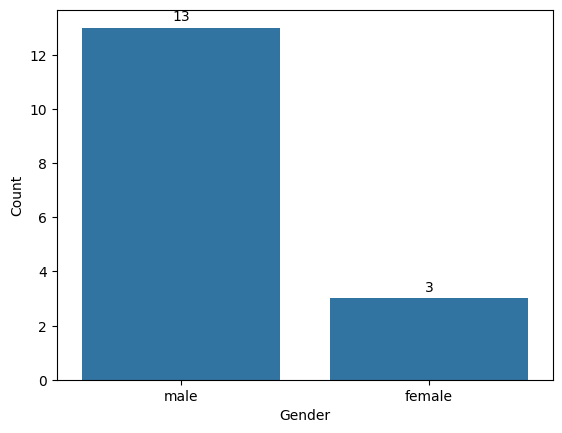

In [9]:
#  male apeared twice, must be whitespace in one of them
participants_overview["Gender"] = [gndr.strip() for gndr in participants_overview["Gender"]]
ax = sns.countplot(data=participants_overview, x="Gender")
ax.set(xlabel="Gender", ylabel="Count")
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()

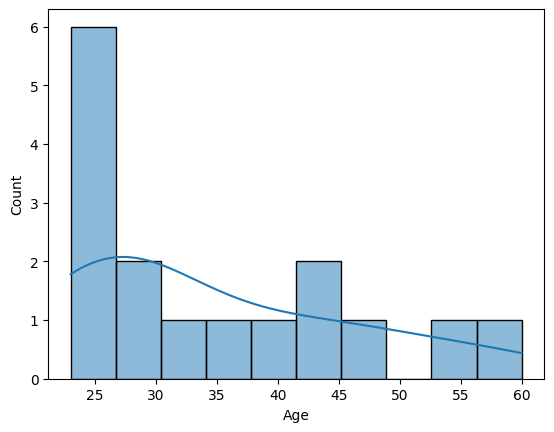

In [10]:
sns.histplot(data=participants_overview, x="Age", bins=10, kde=True)
plt.show()

## Data folders

In [11]:
for participant_path in RAW_DATA_DIR.iterdir():
    if participant_path.is_dir():
        file_count = sum(1 for p in participant_path.rglob("*") if p.is_file())
        print(participant_path.name, file_count)


p12 15
p06 17
p02 17
p03 153
p10 17
p15 16
p05 203
p09 17
p16 17
p11 17
p04 17
p07 17
p14 17
p08 16
p01 338
p13 16


Some participants have food images so they have more files than usual.

## Exploring Participant data for p01

- Fitbit data is in JSON format in fitbit directory
- there are food images 
- googledocs folder contains the : self-report
- pmsys has csv data

#### Step data from fitbit

In [12]:

steps_path = RAW_DATA_DIR / "p01" / "fitbit" / "steps.json"

steps_df = pd.read_json(steps_path)
steps_df.head()

,dateTime,value
0,2019-11-01 00:00:00,0
1,2019-11-01 00:01:00,0
2,2019-11-01 00:02:00,0
3,2019-11-01 00:03:00,0
4,2019-11-01 00:04:00,0


<Axes: >

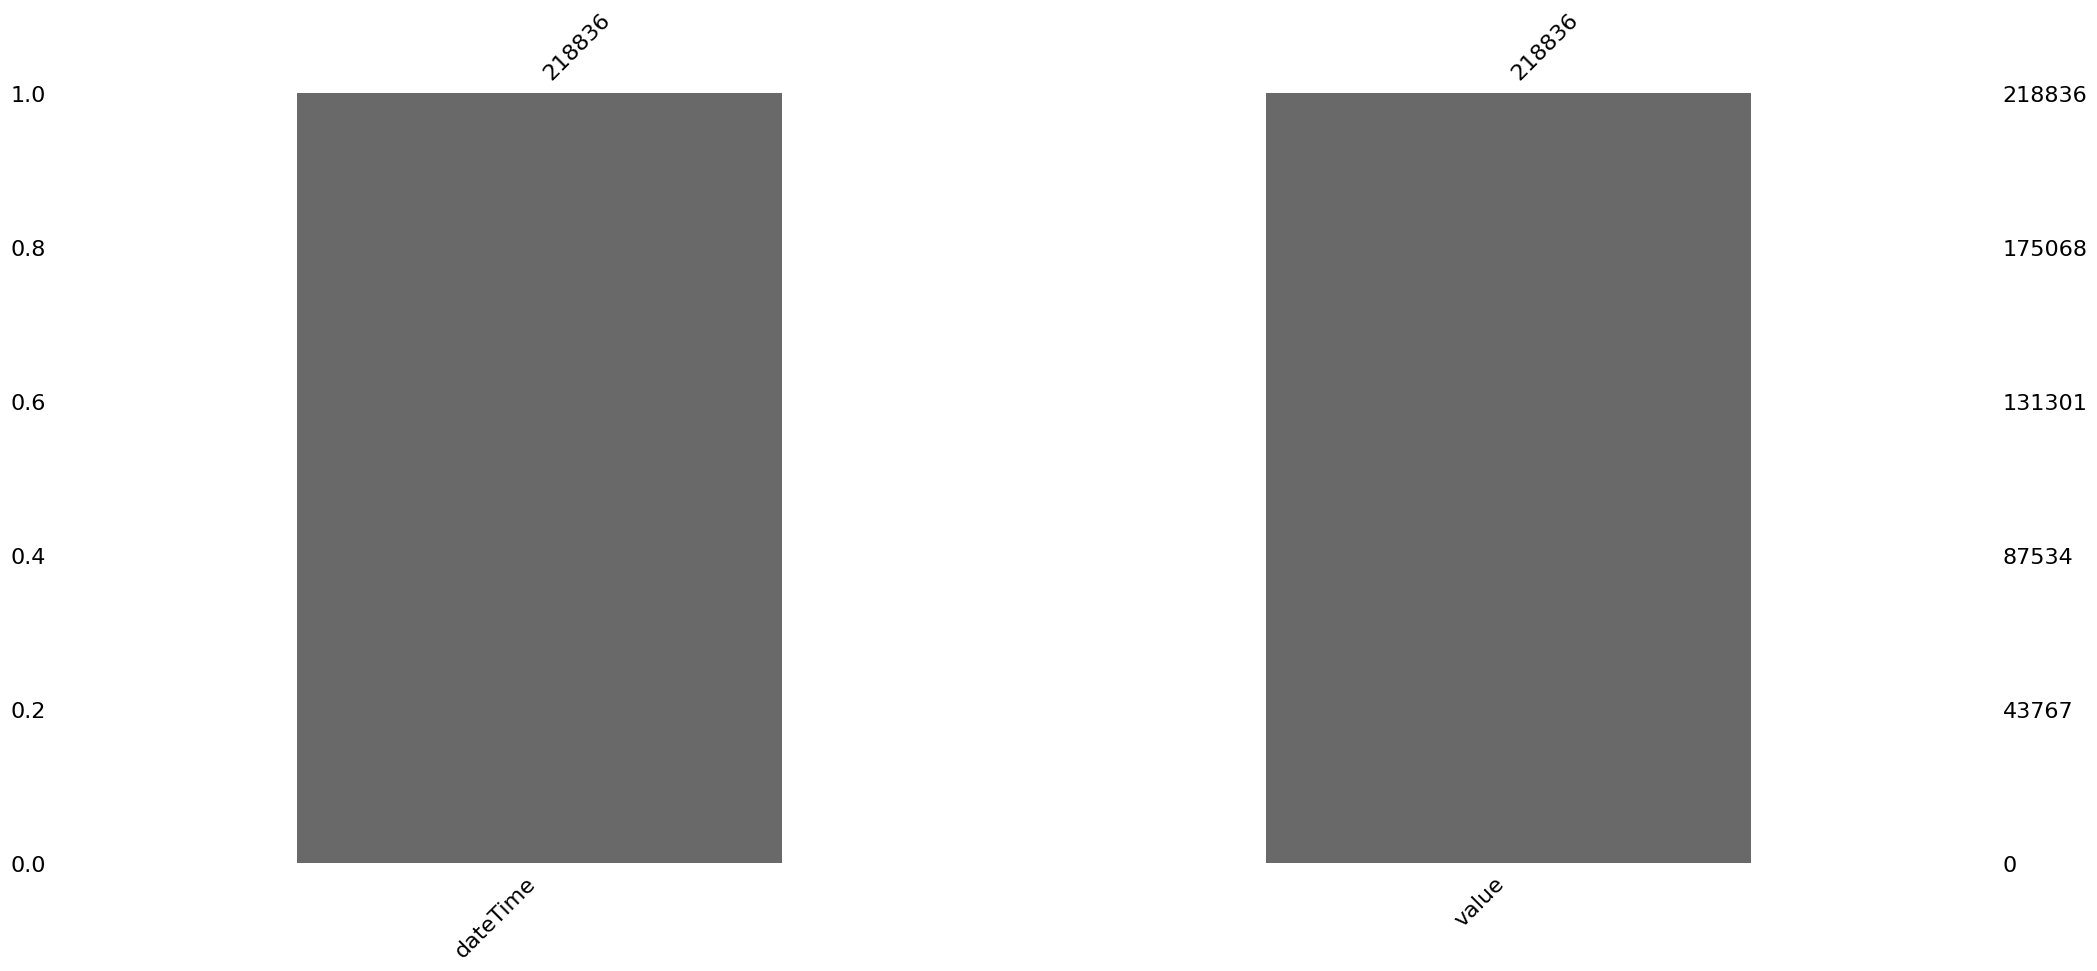

In [13]:
msno.bar(steps_df) # missing counts

In [14]:
steps_df["dateTime"] = pd.to_datetime(steps_df["dateTime"])
steps_df["value"] = pd.to_numeric(steps_df["value"])

daily_steps = (
    steps_df
    .set_index("dateTime")
    .resample("D")["value"]
    .sum()
    .reset_index()
)


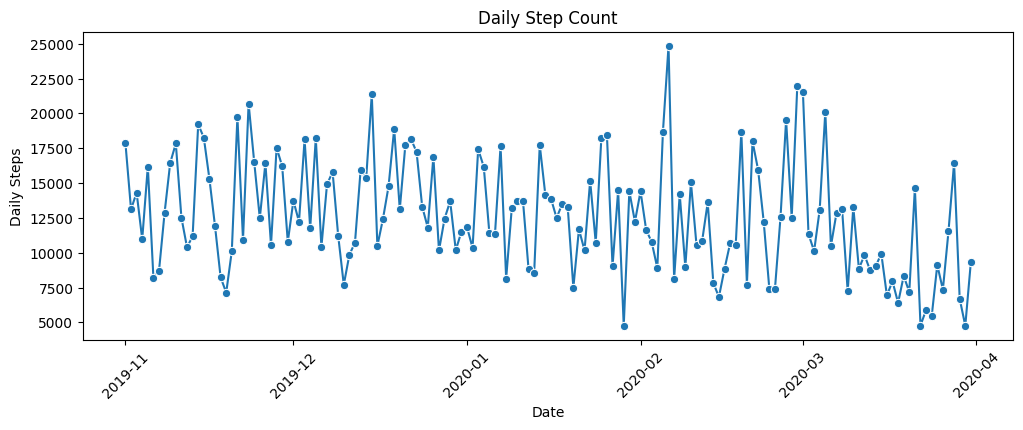

In [15]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=daily_steps, x="dateTime", y="value", marker="o")
plt.xlabel("Date")
plt.ylabel("Daily Steps")
plt.title("Daily Step Count")
plt.xticks(rotation=45)
plt.show()


#### Sleep data from fitbit

In [16]:

sleep_path = RAW_DATA_DIR / "p01" / "fitbit" / "sleep.json"

sleep_df = pd.read_json(sleep_path)
sleep_df.head()

,logId,dateOfSleep,startTime,endTime,duration,minutesToFallAsleep,minutesAsleep,minutesAwake,minutesAfterWakeup,timeInBed,efficiency,type,infoCode,levels,mainSleep
0,24486013387,2019-11-02,2019-11-02 00:09:30,2019-11-02T07:19:30.000,25800000,0,378,52,0,430,97,stages,0,"{'summary': {'deep': {'count': 2, 'minutes': 3...",True
1,24497341340,2019-11-03,2019-11-03 00:32:00,2019-11-03T07:34:30.000,25320000,0,378,44,0,422,96,stages,0,"{'summary': {'deep': {'count': 2, 'minutes': 3...",True
2,24507914069,2019-11-04,2019-11-03 23:55:30,2019-11-04T06:35:00.000,23940000,0,361,38,0,399,96,stages,0,"{'summary': {'deep': {'count': 2, 'minutes': 3...",True
3,24521896102,2019-11-05,2019-11-05 00:22:30,2019-11-05T06:25:00.000,21720000,0,326,36,1,362,99,stages,0,"{'summary': {'deep': {'count': 1, 'minutes': 2...",True
4,24534036899,2019-11-06,2019-11-06 00:25:30,2019-11-06T06:29:30.000,21840000,0,341,23,1,364,99,stages,0,"{'summary': {'deep': {'count': 2, 'minutes': 6...",True


NOTE:: Some columns have nested json objects

In [17]:
sleep_df.shape

(155, 15)

<Axes: >

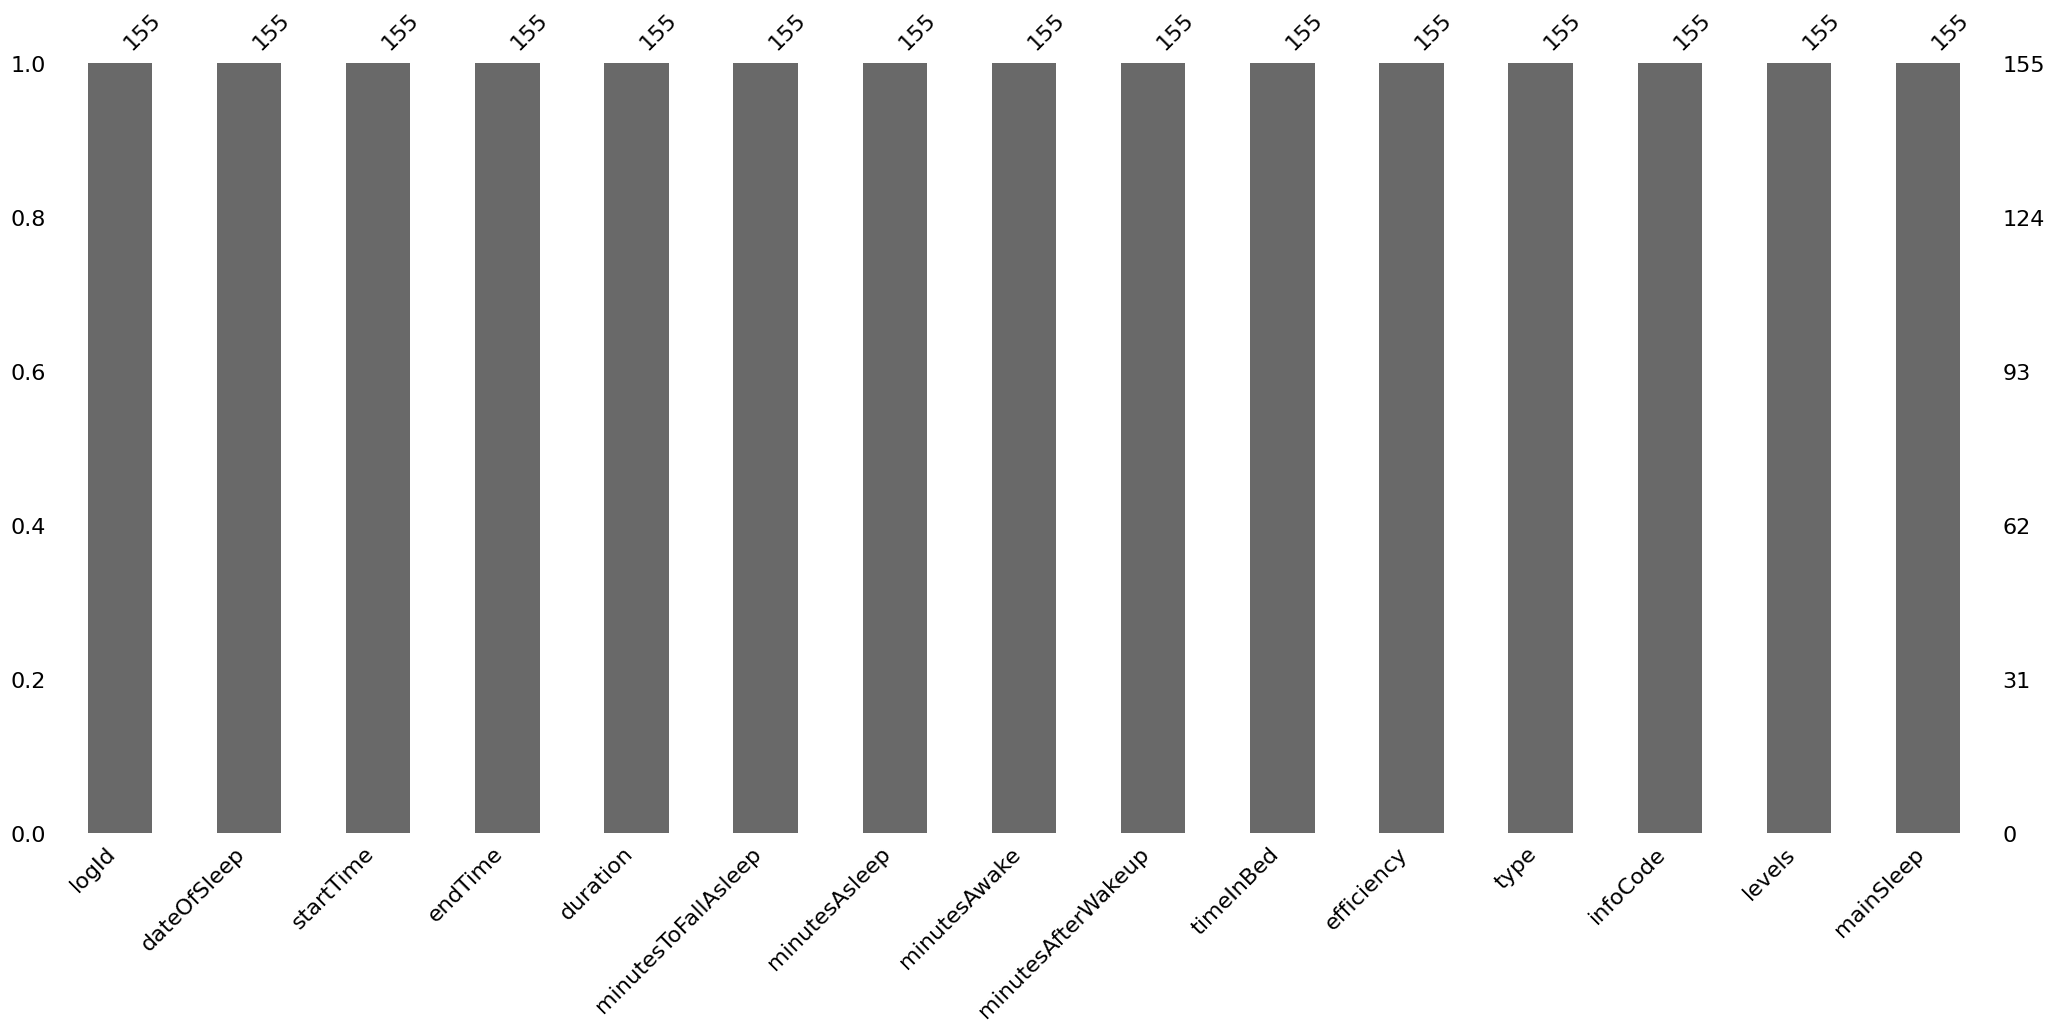

In [18]:
msno.bar(sleep_df)

<Axes: ylabel='efficiency'>

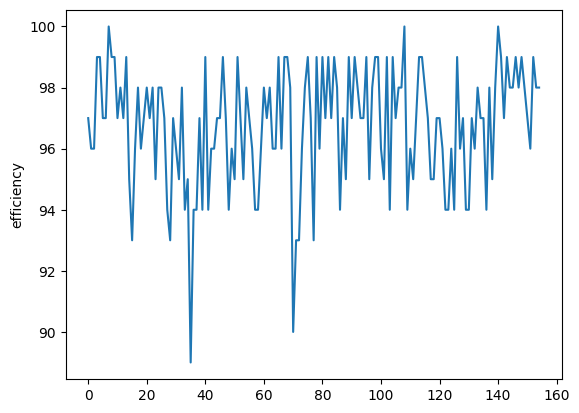

In [19]:
sns.lineplot(sleep_df["efficiency"])

### Heart rate

In [20]:

heart_rate_path = RAW_DATA_DIR / "p01" / "fitbit" / "heart_rate.json"

hr_df = pd.read_json(heart_rate_path)
hr_df.head()

,dateTime,value
0,2019-11-01 00:00:05,"{'bpm': 54, 'confidence': 3}"
1,2019-11-01 00:00:10,"{'bpm': 52, 'confidence': 3}"
2,2019-11-01 00:00:20,"{'bpm': 51, 'confidence': 3}"
3,2019-11-01 00:00:25,"{'bpm': 52, 'confidence': 3}"
4,2019-11-01 00:00:30,"{'bpm': 51, 'confidence': 3}"


value has bpm and confidence in same json object. later we will have to clean up such nested json

### Self Reports (googledocs folder)

In [21]:

reporting_path = RAW_DATA_DIR / "p01" / "googledocs" / "reporting.csv"

reporting_df = pd.read_csv(reporting_path)
reporting_df.head()

,date,timestamp,meals,weight,glasses_of_fluid,alcohol_consumed
0,06/11/2019,06/12/2019 21:58:30,"Breakfast, Dinner",100.0,7,No
1,09/11/2019,09/12/2019 21:17:02,"Breakfast, Evening",100.0,6,No
2,10/11/2019,10/12/2019 21:52:58,"Breakfast, Lunch, Dinner",100.0,9,No
3,11/11/2019,11/11/2019 22:36:30,"Breakfast, Dinner",100.0,5,No
4,12/11/2019,13/11/2019 00:15:47,"Breakfast, Lunch, Dinner",100.0,7,No


<Axes: >

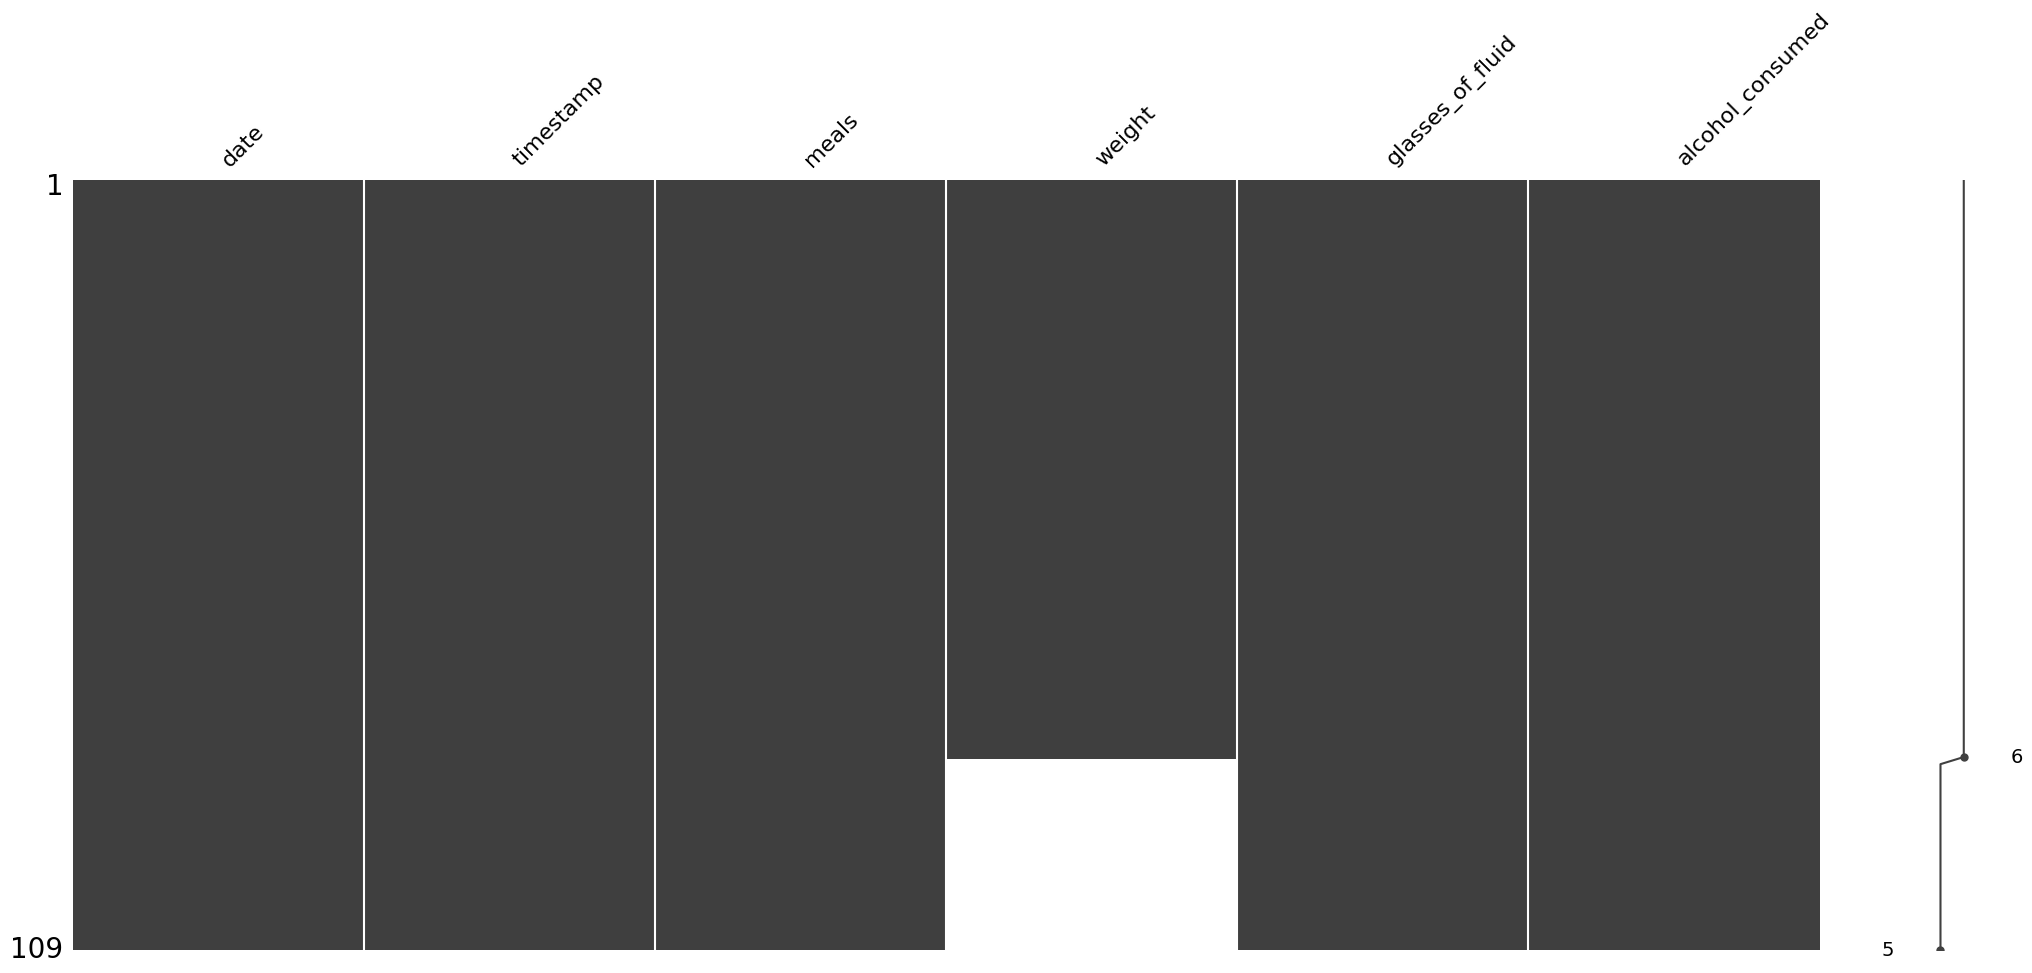

In [22]:
msno.matrix(reporting_df)

Some weight data is missing